<a href="https://colab.research.google.com/github/michelletorres-lang/11.04.26_MVP-Final-An-lise-de-Dados-e-Boas-Pr-ticas-40530010055_20260_01-.ipynb/blob/main/MVP_ML_Machine_Learning_%26_Analytics_Michelle_Julho_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Michelle Helena dos Santos Torres de Araujo_  
**Matrícula:** _4052025000963_  
**Data:** _04/07/2026_  
**Dataset:** _Dados_SISÁGUA_DEZ_a_MAI_  
**Tipo de problema:** _Regressão_  

---


## Checklist do MVP - FINALIZADO

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☑ |
| Dataset descrito, com fonte, atributos e restrições | ☑ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☑ |
| Análise exploratória objetiva, conectada à modelagem | ☑ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☑ |
| Prevenção de vazamento de dados | ☑ |
| Tratamentos de dados justificados | ☑ |
| Pipeline ou sequência reprodutível de pré-processamento | ☑ |
| Modelo baseline definido | ☑ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☑ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☑ |
| Avaliação com métricas coerentes com o problema | ☑ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☑ |
| Código limpo, organizado e executável do início ao fim | ☑ |
| Conclusão conectada ao objetivo inicial | ☑ |

# 1. Definição do problema

## 1.1 Descrição do problema

Este projeto foca na qualidade da água tratada de 30 Estações de Tratamento de Água (ETAs) no
Rio de Janeiro, utilizando dados horários do SISAGUA (dez/2025 a mai/2026). O parâmetro central é a **turbidez**, indicador crítico de pureza física e eficácia da desinfecção por cloro, regulado pela Portaria GM/MS nº 888/2021.

*   **O Desafio:** A turbidez elevada pode 'blindar' microrganismos, reduzindo a eficiência do cloro. Atuar de forma reativa, após a medição fora do padrão, expõe a concessionária a riscos sanitários e regulatórios.
*   **A Solução de ML:** Desenvolver um modelo de regressão para estimar a turbidez futura com base em parâmetros correlacionados (cor, pH, cloro) e no histórico recente (lags).
*   **Impacto Esperado:** Fornecer à equipe de operação uma janela de tempo para ajustes preventivos (ex: dosagem de coagulantes), transformando a gestão de qualidade de reativa para preditiva.
*   **Interessados:** Supervisores de operação, técnicos de laboratório e áreas de conformidade regulatória.



## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  
> _O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a turbidez (NTU) de leituras horárias de água tratada a partir de parâmetros físico-químicos correlacionados (cor, cloro residual livre, pH, flúor), da identificação da estação de tratamento e de valores defasados (lag) da própria série temporal, comparando uma abordagem baseline de persistência com modelos candidatos (Ridge e Random Forest) e discutindo suas limitações práticas para uso operacional._


## 1.3 Tipo de problema

**Tipo escolhido:** _Regressão, com tratamento de série temporal na divisão treino/teste._  
**Justificativa:** _A turbidez é uma variável numérica contínua, então é regressão (não classificação). Como os dados são leituras horárias por estação com forte autocorrelação, usamos regressão com atributos de lag, mas dividimos treino/teste respeitando a ordem cronológica — sem embaralhar — para não vazar informação do futuro para o passado._


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. _A Cor (UC) está fortemente correlacionada com a Turbidez, pois ambas refletem material particulado/dissolvido presente na água._
2. _A turbidez de uma leitura está fortemente correlacionada com a leitura da hora anterior na mesma ETA (autocorrelação temporal) — ao ponto de um baseline simples de persistência já ter desempenho relevante._
3. _Diferentes ETAs têm padrões de turbidez distintos, dependendo do manancial e do processo de tratamento — incluir a identificação da ETA deve melhorar a previsão em relação a um modelo único e "cego" quanto à estação._

**Critérios de sucesso:**
- Métrica principal: RMSE (Root Mean Squared Error), na mesma unidade da turbidez (NTU) — facilita interpretação prática direta (ex.: "o modelo erra em média X NTU").
- Resultado mínimo esperado: superar o baseline de persistência (prever a última turbidez observada) em pelo menos 15% de redução no RMSE.
- Restrição prática: o modelo final deve manter interpretabilidade suficiente para a equipe operacional entender quais variáveis mais influenciam a previsão (ex.: via importância de atributos do Random Forest), evitando soluções "caixa-preta" que dificultem a adoção prática pela equipe de laboratório._


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


## 2.1 Dependências adicionais



> **Comentário:** Não aplicável.


## 2.2 Funções auxiliares

> **Comentário:**
-  Função 1 : Não utilizada;

- Função 2: calcula as três métricas principais de regressão de uma vez:

MAE (erro absoluto médio)
RMSE (raiz do erro quadrático médio — sua métrica principal, definida na seção 1.4)
R² (quanto da variação da turbidez o modelo consegue explicar);

- Fução 3: Adiciona dicionário de resultados e transforma numa tabela (DataFrame) organizada, fácil de comparar visualmente — gerando tabela de métricas lado a lado.


In [35]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

- Dataset: SISAGUA — Controle Mensal, Água Tratada (Ministério da Saúde), extrato operacional com leituras horárias de 30 Estações de Tratamento de Água (ETAs) do Rio de Janeiro.
- Link/fonte: dados operacionais reais da concessionária, no mesmo padrão enviado ao Sisagua (https://www.gov.br/saude/pt-br/composicao/svsa/saude-ambiental/vigiagua/sisagua); disponibilizados neste projeto via repositório público no GitHub.
- Por que foi escolhido: ao contrário dos extratos públicos agregados do Sisagua (que trazem apenas estatísticas mensais — percentil 95, contagens por faixa), esta base traz o valor bruto de cada leitura individual, essencial para um problema real de regressão, com granularidade horária suficiente para explorar autocorrelação temporal.
- Restrições/condições: cobre apenas 30 ETAs do Rio de Janeiro; período de 6 meses (dez/2025 a mai/2026), sem captar variação interanual; o parâmetro Flúor tem alta taxa de ausência (nem toda ETA fluoreta); não há dados de vazão ou precipitação nesta extração.
- Ética/privacidade/licença: dados públicos disponíveis no site do ministério da saúde.


## 3.2 Carga dos dados

> **Comentário:** Os dados são carregados diretamente de uma URL pública (ver célula abaixo). O pré-processamento inicial (conversão de decimais, tratamento de outliers de digitação, construção do timestamp e engenharia de atributos de lag) é feito na própria célula de carga, pois esses passos dependem da ordenação temporal bruta do arquivo original — antes da divisão treino/teste.


In [36]:
import pandas as pd
import numpy as np

USE_EXAMPLE_DATA = False # Define this variable

if USE_EXAMPLE_DATA:
    # Dataset sintético apenas para o template executar.
    n = 500
    df = pd.DataFrame({
        "idade_cliente": np.random.randint(18, 75, size=n),
        "renda_mensal": np.random.normal(5000, 1800, size=n).clip(800, None),
        "tempo_relacionamento_meses": np.random.randint(1, 120, size=n),
        "canal_aquisicao": np.random.choice(["orgânico", "ads", "indicação"], size=n),
        "usa_app": np.random.choice(["sim", "não"], size=n, p=[0.7, 0.3]),
    })

    # Target sintético para exemplo de classificação.
    score = (
        -0.03 * df["idade_cliente"]
        -0.01 * df["tempo_relacionamento_meses"]
        + 0.00025 * df["renda_mensal"]
        + (df["usa_app"] == "não").astype(int) * 0.8
        + np.random.normal(0, 0.8, size=n)
    )
    prob = 1 / (1 + np.exp(-score))
    df["churn"] = (prob > np.quantile(prob, 0.6)).astype(int)
else:
    # parte principal da carga de dados
    url = "https://raw.githubusercontent.com/michelletorres-lang/MVP_ML_Turbidez_SISAGUA/main/Dados_SISAGUA_DEZ_a_MAI.csv"
    df = pd.read_csv(url, encoding='latin1', sep=';')

    # Convert numeric columns with comma decimals to float
    numeric_cols_with_comma = ['Cloro Livre (mg/L)', 'Cor (UC)', 'Turbidez (NTU)', 'Flúor (mg/L)', 'pH (UpH)']
    for col in numeric_cols_with_comma:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
            # Handle cases where conversion to numeric might fail, e.g., if there are non-numeric strings
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Combine Data and Hora into a datetime column
    # Ensure 'Data' and 'Hora' are treated as strings for concatenation before conversion
    df['datetime'] = pd.to_datetime(df['Data'] + ' ' + df['Hora'], format='%d/%m/%Y %H:%M:%S', errors='coerce')

    # Drop rows where datetime conversion failed (if any)
    df.dropna(subset=['datetime'], inplace=True)

    # Sort data by ETA and datetime for correct lag feature calculation
    df.sort_values(by=['Ident. do Componente', 'datetime'], inplace=True)

    # Create lag features (turbidez, cor, cloro, pH)
    df['turbidez_lag1'] = df.groupby('Ident. do Componente')['Turbidez (NTU)'].shift(1)
    df['cor_lag1'] = df.groupby('Ident. do Componente')['Cor (UC)'].shift(1)
    df['cloro_lag1'] = df.groupby('Ident. do Componente')['Cloro Livre (mg/L)'].shift(1)
    df['ph_lag1'] = df.groupby('Ident. do Componente')['pH (UpH)'].shift(1)

    # Extract temporal features
    df['hora_dia'] = df['datetime'].dt.hour
    df['dia_semana'] = df['datetime'].dt.dayofweek # Monday=0, Sunday=6
    df['mes'] = df['datetime'].dt.month

    # Rename columns for consistency (snake_case)
    df.rename(columns={
        'Estado ': 'estado',
        'Ident. do Componente': 'eta',
        'Elemento': 'elemento',
        'Data': 'data_original', # Keep original if needed for reference, but use 'datetime' for time series
        'Hora': 'hora_original', # Same as above
        'Cloro Livre (mg/L)': 'cloro_livre',
        'Cor (UC)': 'cor',
        'Turbidez (NTU)': 'turbidez',
        'Flúor (mg/L)': 'fluor',
        'pH (UpH)': 'ph'
    }, inplace=True)

    # Handle pH outlier: replace 733 with NaN as per problem description (and impute later)
    df['ph'].replace(733, np.nan, inplace=True)

    # Drop constant columns and original date/time columns
    df.drop(columns=['estado', 'elemento', 'data_original', 'hora_original'], inplace=True, errors='ignore')

# Now display head
df.head()

/tmp/ipykernel_8057/3437111456.py:76: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ph'].replace(733, np.nan, inplace=True)


,eta,cloro_livre,cor,turbidez,fluor,ph,datetime,turbidez_lag1,cor_lag1,cloro_lag1,ph_lag1,hora_dia,dia_semana,mes
95787,ETA Aperibé,1.10,4.4,0.10,NaN,7.0,2025-12-01 01:00:00,NaN,NaN,NaN,NaN,1,0,12
95823,ETA Aperibé,1.24,3.5,0.92,0.61,6.8,2025-12-01 02:00:00,0.10,4.4,1.10,7.0,2,0,12
95829,ETA Aperibé,1.18,5.2,0.72,NaN,6.9,2025-12-01 03:00:00,0.92,3.5,1.24,6.8,3,0,12
95860,ETA Aperibé,1.16,4.4,0.80,0.55,6.8,2025-12-01 04:00:00,0.72,5.2,1.18,6.9,4,0,12
95871,ETA Aperibé,1.08,3.3,0.37,NaN,7.0,2025-12-01 05:00:00,0.80,4.4,1.16,6.8,5,0,12


## 3.3 Visão geral do dataset

**O dataset inclui:**
- Linhas/colunas: 114.745 leituras brutas → 14 colunas após limpeza e engenharia de atributos
- Tipos: eta categórica; hora_dia/dia_semana/mes numéricas discretas; cor, cloro_livre, ph, fluor e os 4 lags numéricas contínuas; datetime usada só para ordenação/split
- Ausentes: Flúor ~37%, pH ~4,4%, Cor ~3,1%, Turbidez e Cloro Livre ~2,4% — tratados via imputação (mediana)
- Duplicatas: nenhuma linha duplicada identificada (ETA + timestamp é chave única)
- Colunas descartadas: datetime (só para split), Estado e Elemento (constantes, sem variância)
- Target: turbidez (NTU) — numérica contínua, distribuição concentrada em valores baixos com cauda à direita (picos pontuais)




In [37]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (114745, 14)

Tipos de dados:


,tipo
eta,object
cloro_livre,float64
cor,float64
turbidez,float64
fluor,float64
ph,float64
datetime,datetime64[ns]
turbidez_lag1,float64
cor_lag1,float64
cloro_lag1,float64


In [38]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
eta,0
cloro_livre,2734
cor,3594
turbidez,2809
fluor,42551
ph,5107
datetime,0
turbidez_lag1,2839
cor_lag1,3624
cloro_lag1,2764


In [39]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [40]:
SEED = 42 # It's good practice to define SEED at the beginning of your notebook for reproducibility
display(df.sample(5, random_state=SEED))

,eta,cloro_livre,cor,turbidez,fluor,ph,datetime,turbidez_lag1,cor_lag1,cloro_lag1,ph_lag1,hora_dia,dia_semana,mes
110164,ETA Itaocara,1.15,4.9,1.51,0.66,6.4,2025-12-24 14:00:00,1.63,5.0,1.12,6.4,14,2,12
79844,ETA Cambuci,1.07,11.4,4.05,NaN,6.9,2026-01-06 02:00:00,3.38,11.7,1.06,6.1,2,1,1
57651,ETA Tanguá,2.14,3.0,3.80,0.62,6.6,2026-03-29 06:00:00,4.35,3.3,2.24,6.6,6,6,3
98655,ETA Monerat,1.16,1.9,0.10,NaN,5.8,2025-12-05 19:00:00,0.10,2.7,1.12,5.8,19,4,12
1836,ETA Venda das Flores,1.18,3.4,0.61,0.81,6.6,2026-05-03 22:00:00,0.51,3.8,1.21,6.5,22,6,5


## 3.4 Dicionário de dados

Tabela de atributos

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| datetime | data | Timestamp da leitura (data + hora) | não | usada só para ordenar e dividir treino/teste |
| eta | categórica | Identificação da estação de tratamento (30 categorias) | sim | captura efeito fixo de cada estação/manancial |
| cor | numérica | Cor aparente da água tratada (UC) | sim | maior correlação linear direta com a turbidez |
| cloro_livre | numérica | Cloro residual livre (mg/L) | sim | indicador indireto do processo de desinfecção |
| ph | numérica | pH da água tratada | sim | outliers de digitação tratados (ex.: 733 → removido) |
| fluor | numérica | Flúor (mg/L) | sim | ~37% de ausência; imputação necessária |
| hora_dia | numérica (0–23) | Hora da leitura | sim | captura padrão diário de operação |
| dia_semana | numérica (0–6) | Dia da semana | sim | captura possível padrão semanal |
| mes | numérica (1–12) | Mês da leitura | sim | proxy fraca de sazonalidade (só 6 meses disponíveis) |
| turbidez_lag1 | numérica | Turbidez da leitura anterior (mesma ETA) | sim | feature mais forte esperada (autocorrelação) |
| cor_lag1 | numérica | Cor da leitura anterior (mesma ETA) | sim | complementa o histórico recente |
| cloro_lag1 | numérica | Cloro livre da leitura anterior (mesma ETA) | sim | complementa o histórico recente |
| ph_lag1 | numérica | pH da leitura anterior (mesma ETA) | sim | complementa o histórico recente |
| turbidez | alvo | Turbidez (NTU) da leitura atual | alvo | variável a ser prevista |

# 4. Análise exploratória dos dados

**O que incluir:**
- A análise exploratória a seguir foi conduzida com foco direto no problema de previsão de turbidez: cada gráfico busca responder a uma pergunta relevante para a modelagem, não apenas descrever a base de forma genérica.


- Distribuição do target: a turbidez apresenta distribuição assimétrica à direita — concentração de leituras em valores baixos (água dentro do padrão da Portaria 888/2021) e uma cauda de valores mais altos, associada a eventos pontuais de piora.
- Distribuição de variáveis importantes: Cor, Cloro Livre e pH foram inspecionados individualmente; outliers de digitação (ex.: pH = 733) foram identificados e tratados antes da modelagem.
- Relação entre variáveis e target: a Cor (UC) mostra a maior correlação linear com a turbidez, confirmando a hipótese física inicial. A turbidez defasada (turbidez_lag1) é esperada como o preditor mais forte, dada a autocorrelação da série horária.
- Padrões relevantes: há diferença clara de turbidez média entre ETAs, o que justifica manter a identificação da estação como variável categórica no modelo, em vez de tratar todas as estações como equivalentes.
- Hipóteses geradas a partir dos dados: a forte autocorrelação sugere que um baseline de persistência (usar a leitura anterior como previsão) já será competitivo — o que reforça a necessidade de comparar os modelos candidatos contra esse baseline específico, e não contra uma média/mediana genérica.


In [41]:
TARGET = "turbidez"
PROBLEM_TYPE = "serie_temporal"

if TARGET is not None and TARGET in df.columns:
    print(f"Target variable set to: {TARGET}")
else:
    print(f"Target variable '{TARGET}' not found in DataFrame.")

Target variable set to: turbidez


In [18]:
# This cell will be cleared as detailed EDA will be performed in new generated cells.

### 4.1 Visão Geral e Estatísticas Descritivas

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Informações gerais do dataset:")
df.info()
print("\nEstatísticas descritivas (incluindo NaN):")
display(df.describe(include='all'))

Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 114745 entries, 95787 to 19355
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   eta            114745 non-null  object        
 1   cloro_livre    112011 non-null  float64       
 2   cor            111151 non-null  float64       
 3   turbidez       111936 non-null  float64       
 4   fluor          72194 non-null   float64       
 5   ph             109638 non-null  float64       
 6   datetime       114745 non-null  datetime64[ns]
 7   turbidez_lag1  111906 non-null  float64       
 8   cor_lag1       111121 non-null  float64       
 9   cloro_lag1     111981 non-null  float64       
 10  ph_lag1        109610 non-null  float64       
 11  hora_dia       114745 non-null  int32         
 12  dia_semana     114745 non-null  int32         
 13  mes            114745 non-null  int32         
dtypes: datetime64[ns](1), f

,eta,cloro_livre,cor,turbidez,fluor,ph,datetime,turbidez_lag1,cor_lag1,cloro_lag1,ph_lag1,hora_dia,dia_semana,mes
count,114745,112011.000000,111151.000000,111936.000000,72194.000000,109638.000000,114745,111906.000000,111121.000000,111981.000000,109610.000000,114745.000000,114745.000000,114745.000000
unique,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ETA Itaocara,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.450653,4.758024,0.989127,0.654995,6.739504,2026-03-02 22:08:04.340058624,0.989157,4.758051,1.450634,6.746089,12.631226,3.006362,4.512850
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,2025-12-01 01:00:00,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,NaN,1.170000,1.400000,0.120000,0.600000,6.400000,2026-01-16 21:00:00,0.120000,1.400000,1.170000,6.400000,7.000000,1.000000,2.000000
50%,NaN,1.300000,3.900000,0.530000,0.650000,6.700000,2026-03-04 17:00:00,0.530000,3.900000,1.300000,6.700000,13.000000,3.000000,3.000000
75%,NaN,1.630000,7.300000,1.400000,0.710000,7.000000,2026-04-16 09:00:00,1.400000,7.300000,1.630000,7.000000,18.000000,5.000000,5.000000
max,NaN,178.000000,97.100000,32.300000,2.100000,674.000000,2026-05-31 23:59:00,32.300000,97.100000,178.000000,733.000000,23.000000,6.000000,12.000000


### 4.2 Análise da Variável Target: Turbidez (NTU)

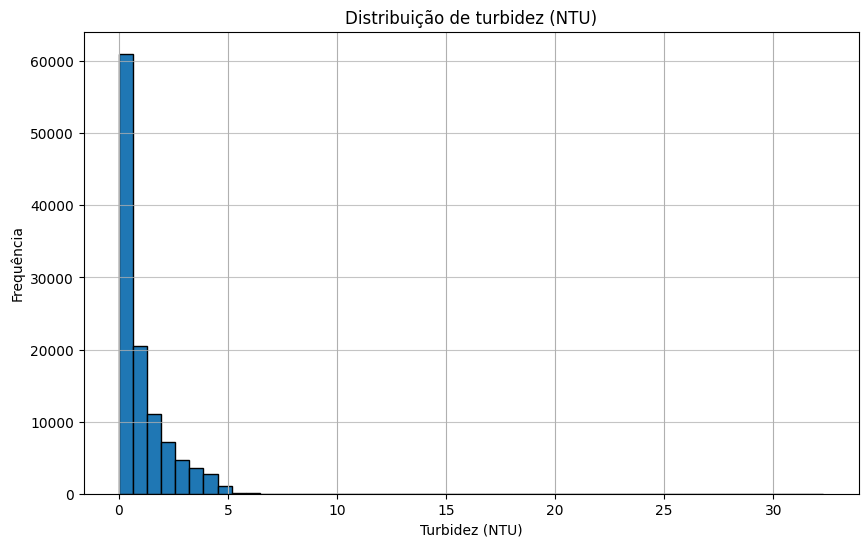

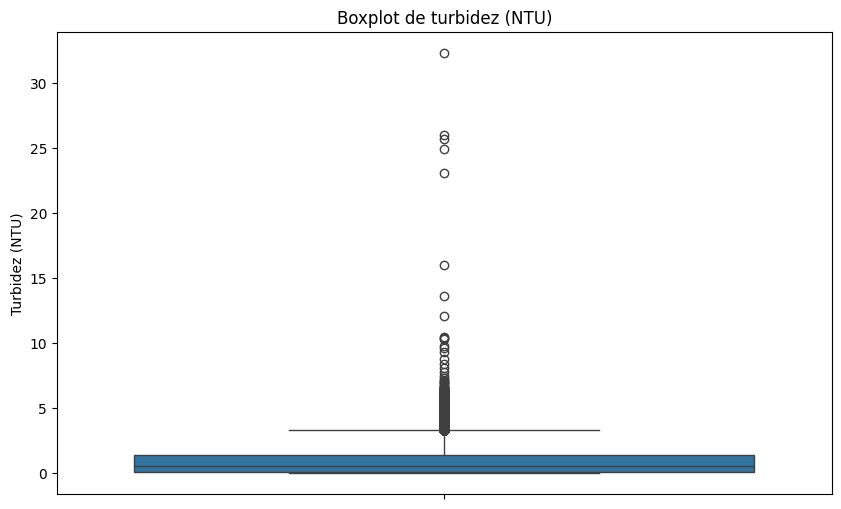

Estatísticas de turbidez (NTU):


,turbidez
count,111936.000000
mean,0.989127
std,1.130009
min,0.000000
25%,0.120000
50%,0.530000
75%,1.400000
max,32.300000



140 leituras (0.12%) estão acima do limite de 5.0 NTU.


In [43]:
plt.figure(figsize=(10, 6))
df[TARGET].hist(bins=50, edgecolor='black')
plt.title(f'Distribuição de {TARGET} (NTU)')
plt.xlabel('Turbidez (NTU)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(y=df[TARGET])
plt.title(f'Boxplot de {TARGET} (NTU)')
plt.ylabel('Turbidez (NTU)')
plt.show()

print(f"Estatísticas de {TARGET} (NTU):")
display(df[TARGET].describe())

# Análise de valores acima de limites regulatórios (ex: > 5 NTU)
# Note: This limit should be defined based on actual regulations.
reg_limit = 5.0 # Exemplo de limite regulatório (Portaria GM/MS nº 888/2021)
above_limit = df[df[TARGET] > reg_limit].shape[0]
total = df.shape[0]
print(f"\n{above_limit} leituras ({above_limit/total:.2%}) estão acima do limite de {reg_limit} NTU.")

### 4.3 Análise de Variáveis Numéricas

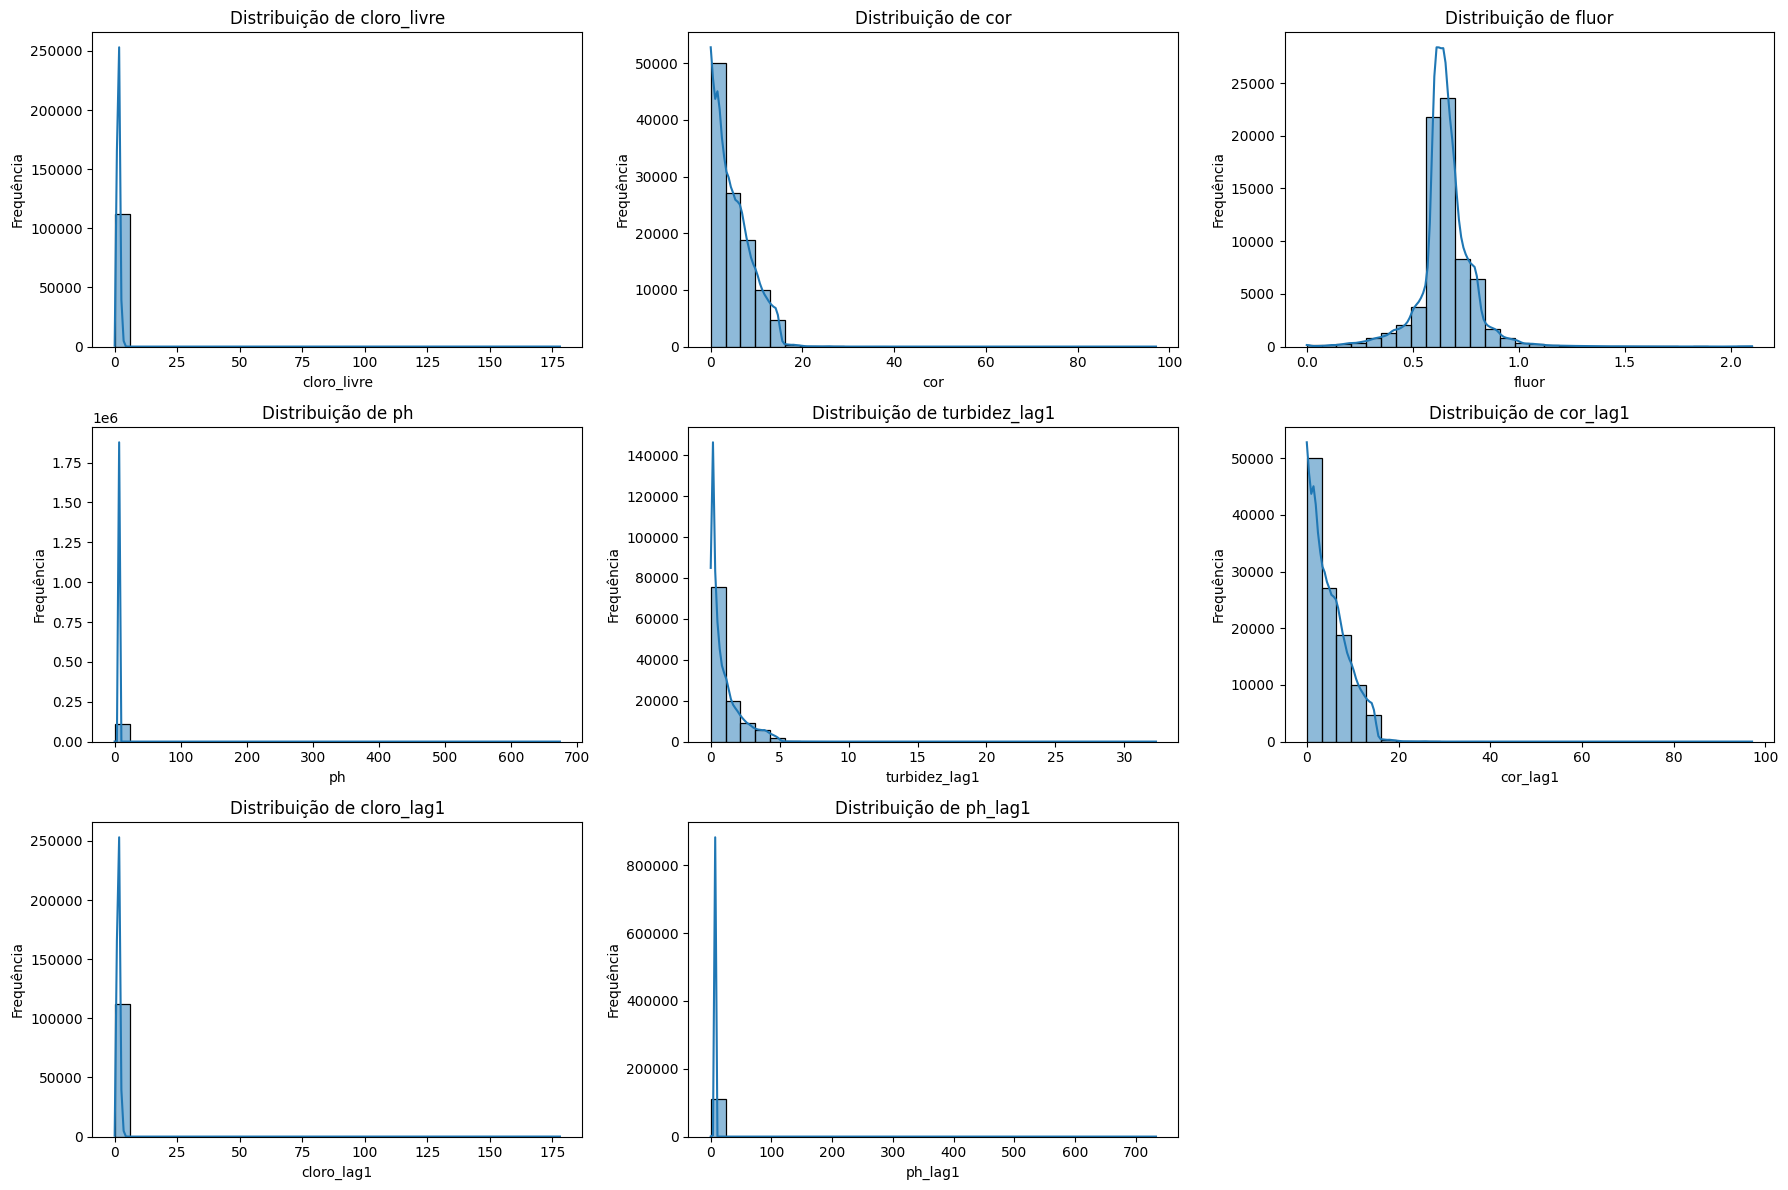

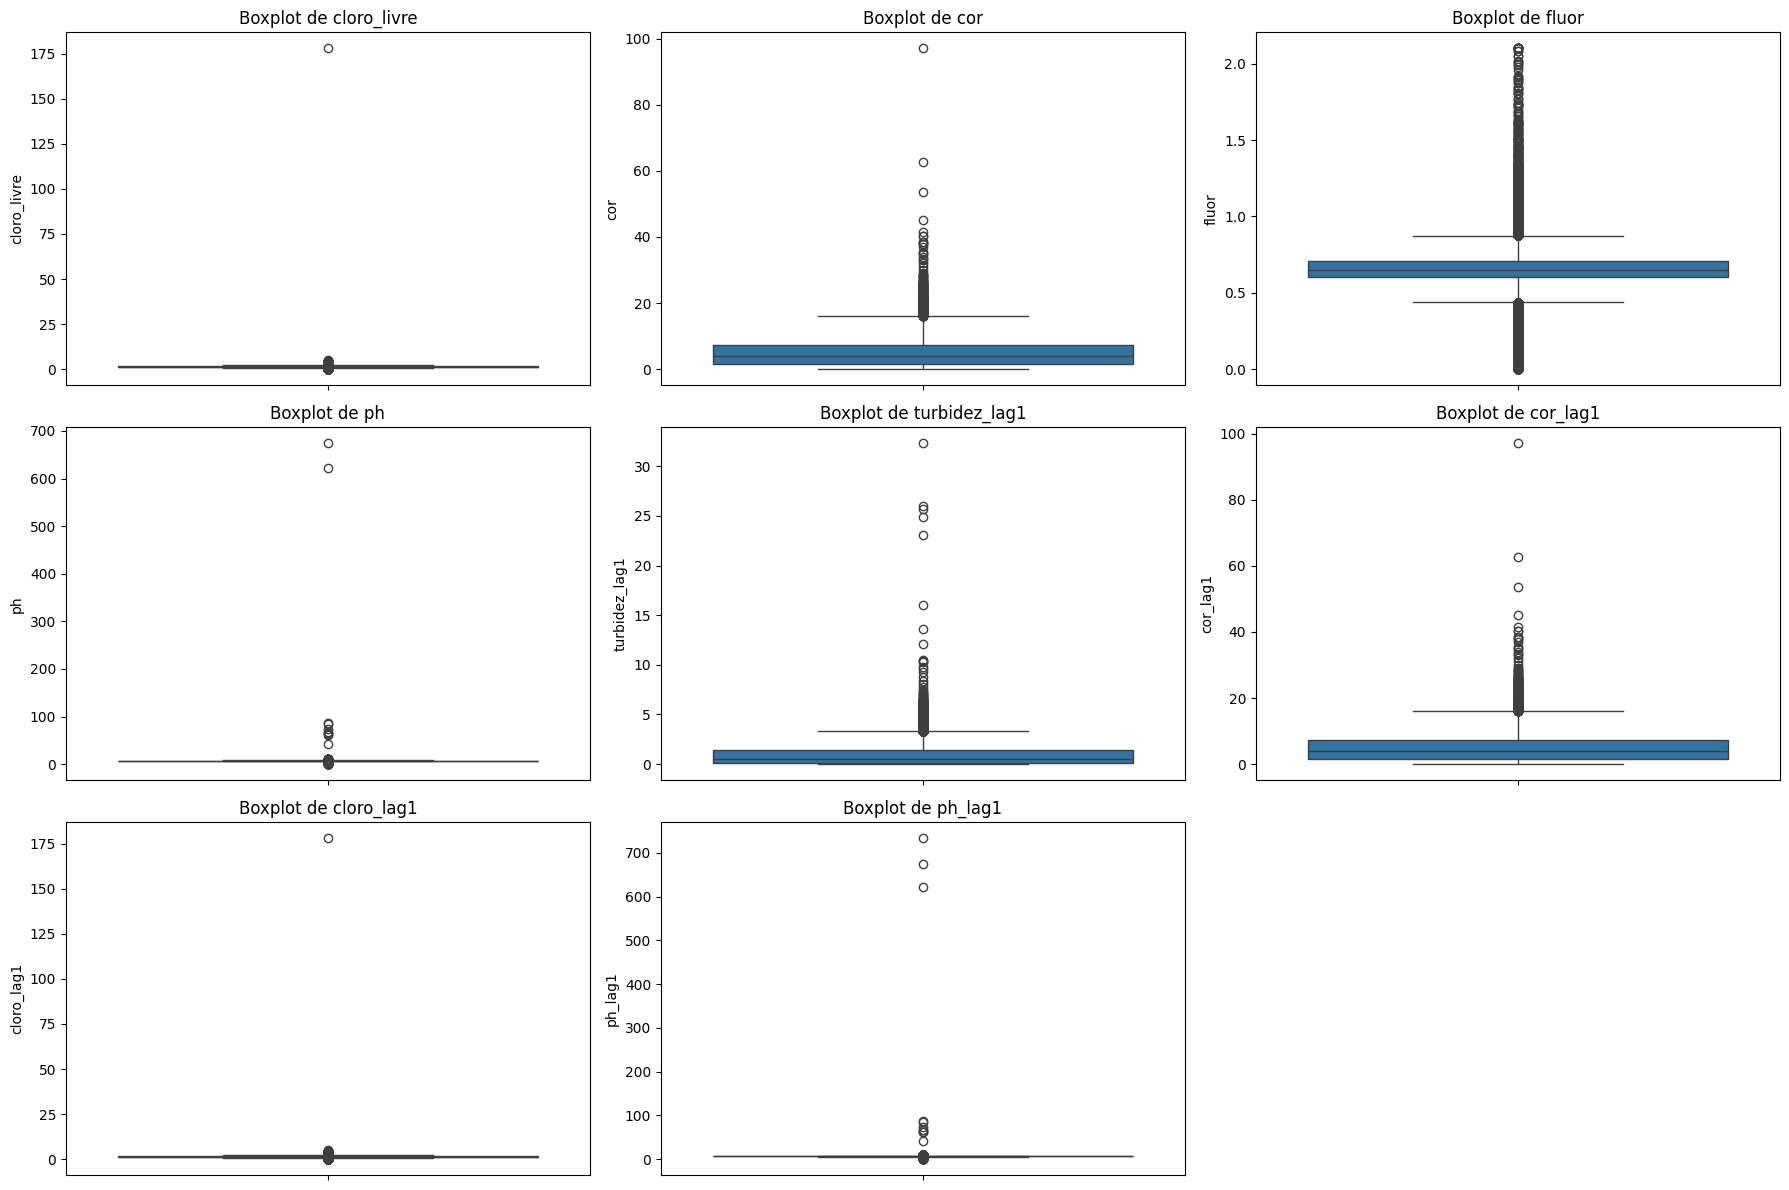

In [44]:
numeric_cols_for_eda = [
    'cloro_livre', 'cor', 'fluor', 'ph',
    'turbidez_lag1', 'cor_lag1', 'cloro_lag1', 'ph_lag1'
]

# Histograms for numerical features
plt.figure(figsize=(18, 12))
for i, col in enumerate(numeric_cols_for_eda):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

# Boxplots for numerical features to visualize outliers
plt.figure(figsize=(18, 12))
for i, col in enumerate(numeric_cols_for_eda):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col].dropna())
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### 4.4 Análise de Variáveis Categóricas e Temporais

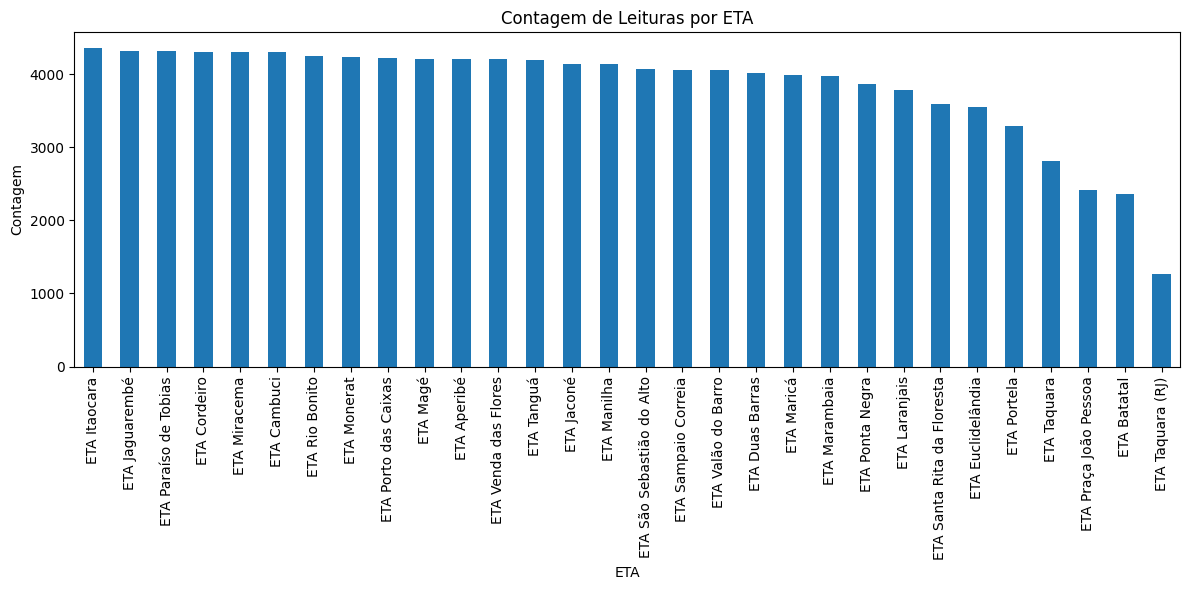

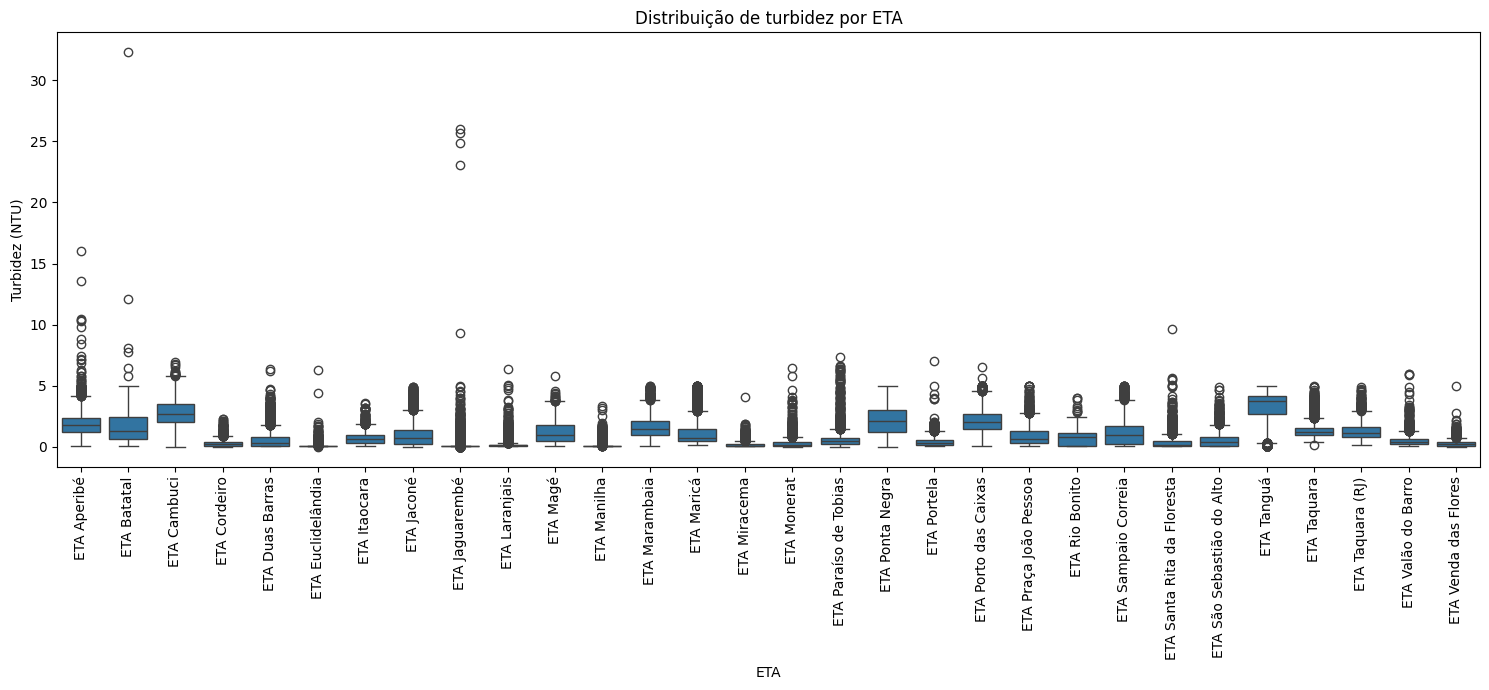

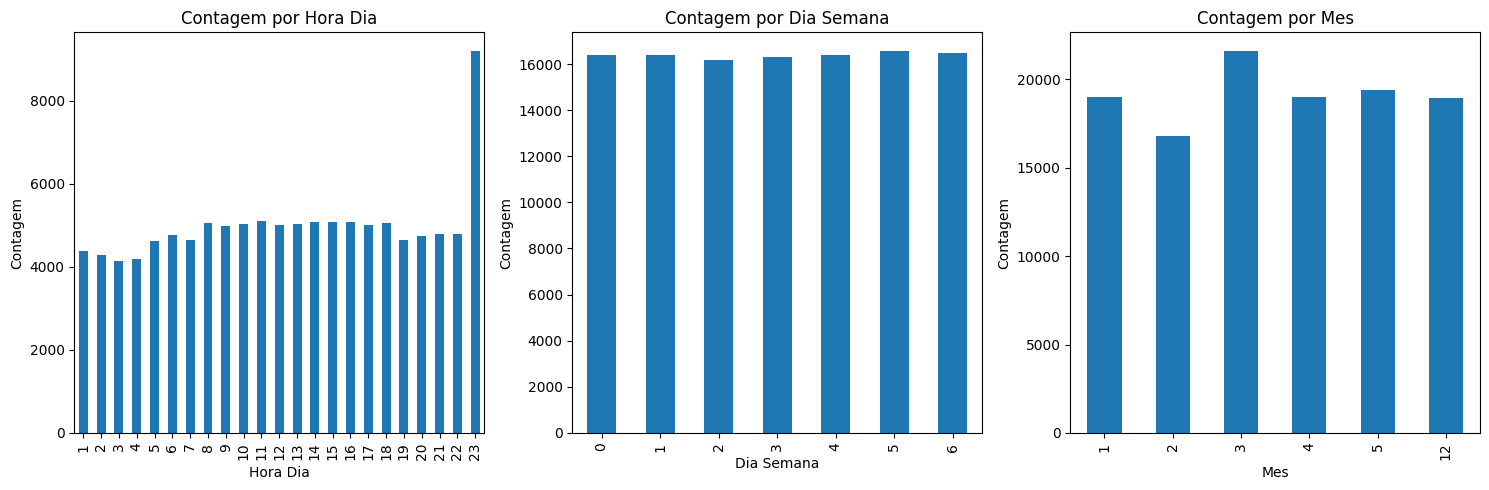

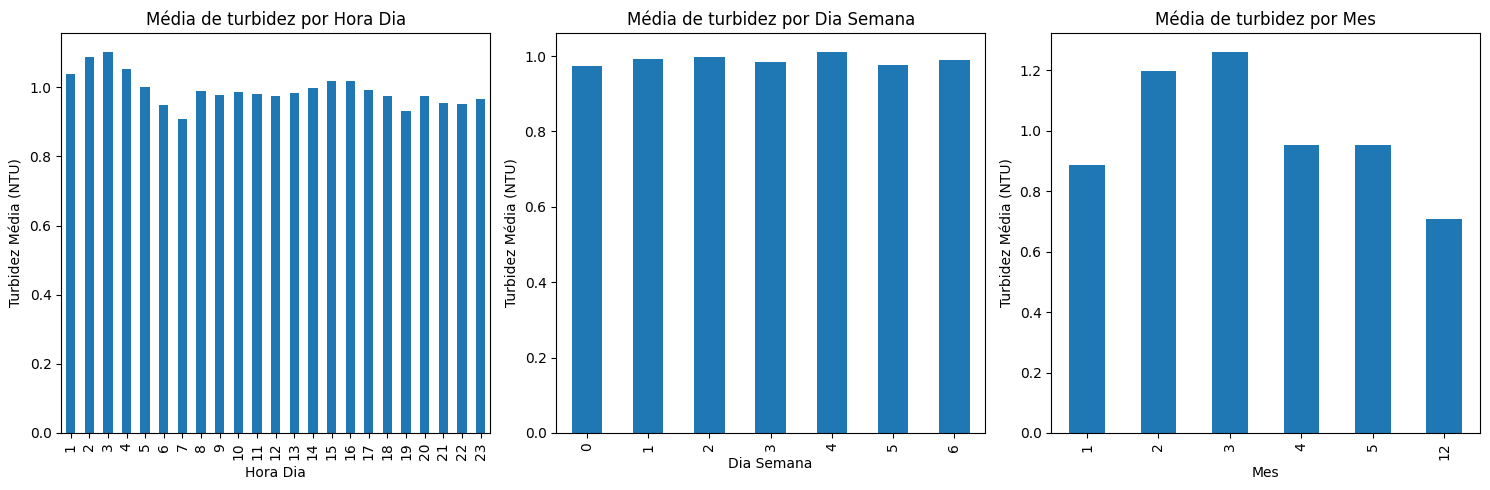

In [45]:
categorical_cols_for_eda = ['eta', 'hora_dia', 'dia_semana', 'mes']

# Analysis of 'eta'
plt.figure(figsize=(12, 6))
df['eta'].value_counts().plot(kind='bar')
plt.title('Contagem de Leituras por ETA')
plt.xlabel('ETA')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Boxplot of Turbidez by ETA to see variability
plt.figure(figsize=(15, 7))
sns.boxplot(x='eta', y=TARGET, data=df)
plt.title(f'Distribuição de {TARGET} por ETA')
plt.xlabel('ETA')
plt.ylabel('Turbidez (NTU)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Temporal features counts
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols_for_eda[1:]): # Skip 'eta' as it's handled above
    plt.subplot(1, 3, i + 1)
    df[col].value_counts().sort_index().plot(kind='bar')
    plt.title(f'Contagem por {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Contagem')
plt.tight_layout()
plt.show()

# Mean Turbidez by temporal features
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols_for_eda[1:]):
    plt.subplot(1, 3, i + 1)
    df.groupby(col)[TARGET].mean().plot(kind='bar')
    plt.title(f'Média de {TARGET} por {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Turbidez Média (NTU)')
plt.tight_layout()
plt.show()

### 4.5 Matriz de Correlação

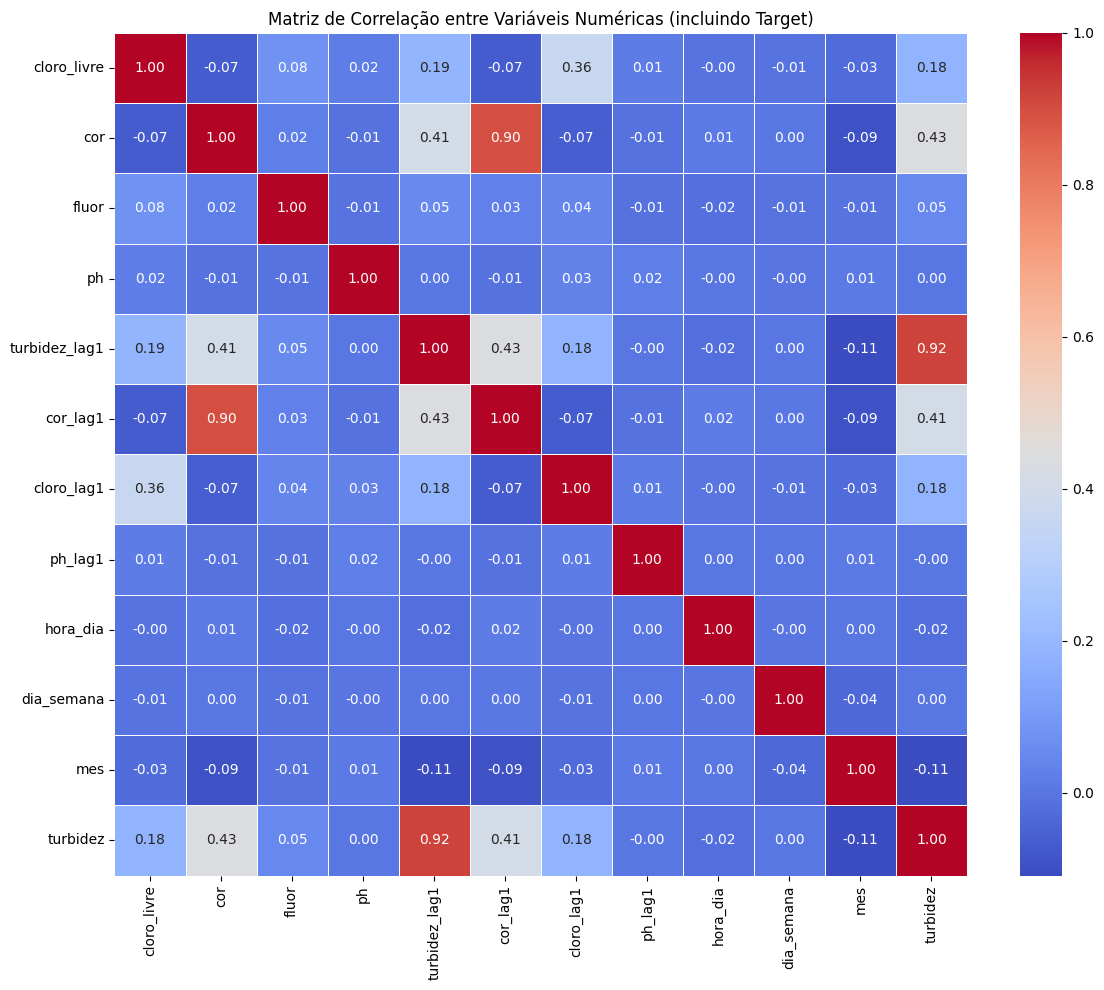


Correlação com o Target (Turbidez):


,turbidez
turbidez,1.000000
turbidez_lag1,0.920897
cor,0.432790
cor_lag1,0.406437
cloro_livre,0.184310
cloro_lag1,0.184053
fluor,0.051026
dia_semana,0.001735
ph,0.001684
ph_lag1,-0.000141


In [46]:
numeric_cols_for_eda = [
    'cloro_livre', 'cor', 'fluor', 'ph',
    'turbidez_lag1', 'cor_lag1', 'cloro_lag1', 'ph_lag1',
    'hora_dia', 'dia_semana', 'mes'
]
# Select only numeric columns for correlation matrix
# Ensure TARGET is included for correlation analysis
numeric_df_for_corr = df[numeric_cols_for_eda + [TARGET]].select_dtypes(include=np.number)
correlation_matrix = numeric_df_for_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas (incluindo Target)')
plt.tight_layout()
plt.show()

print("\nCorrelação com o Target (Turbidez):")
display(correlation_matrix[TARGET].sort_values(ascending=False))

### 4.6 Análise de Padrões Temporais

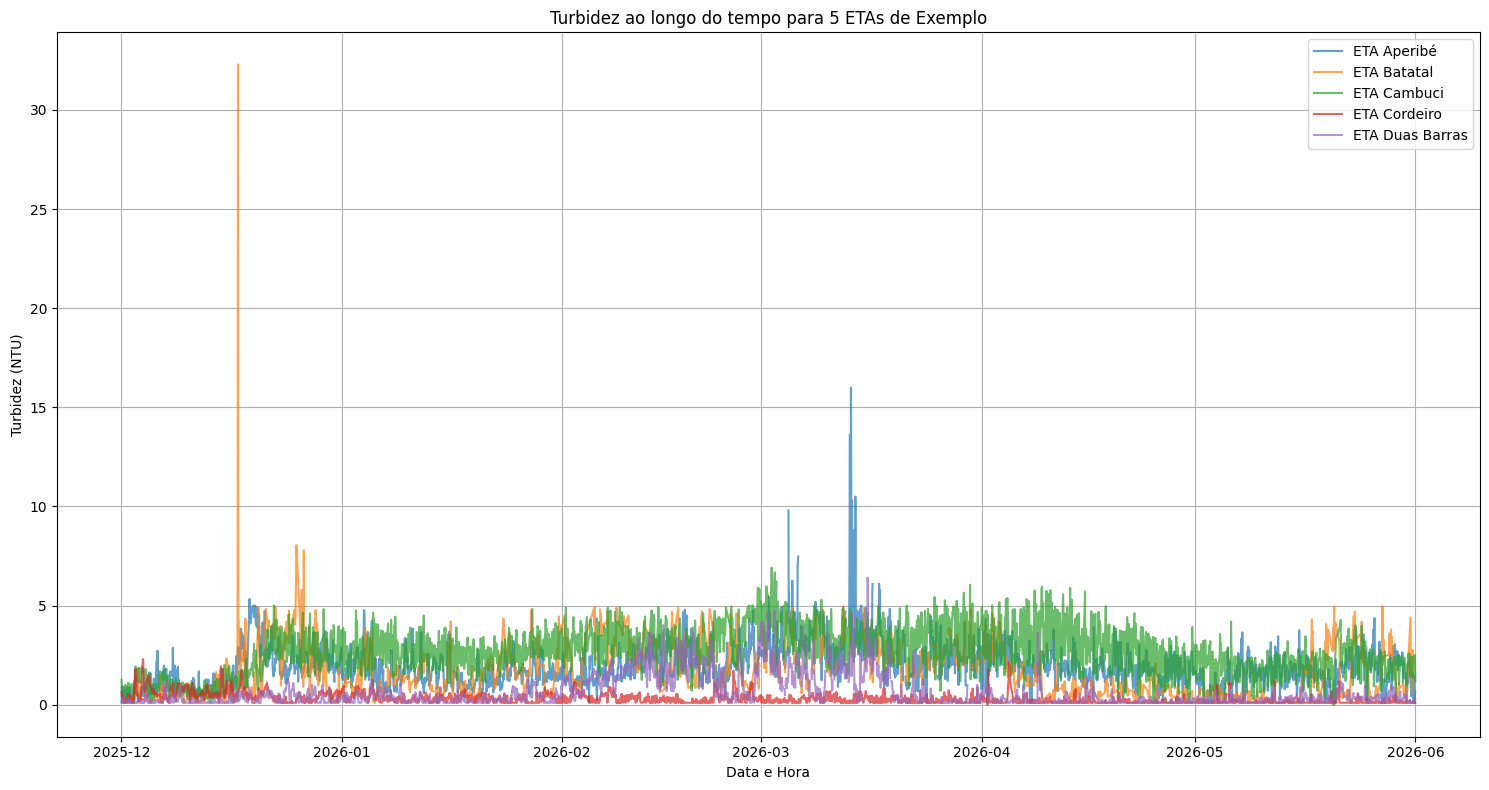

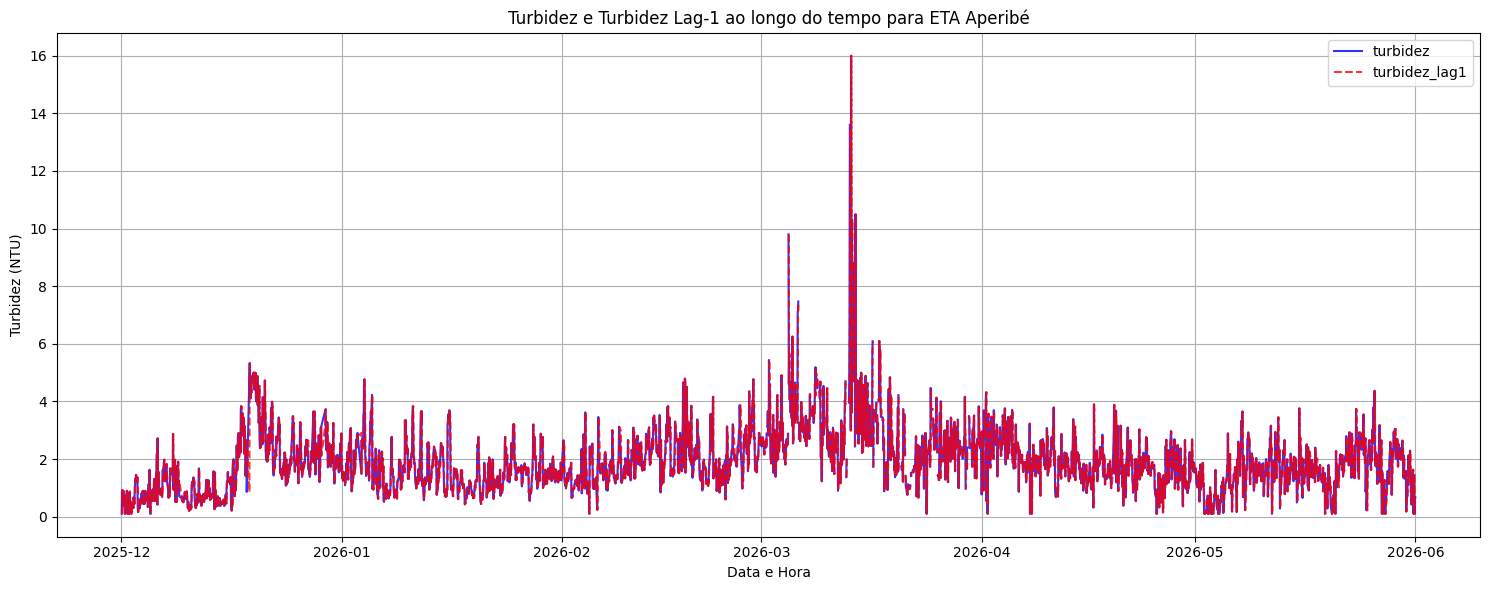

In [47]:
num_etas_to_plot = min(5, df['eta'].nunique())
# Get a sample of unique ETA names
sample_etas = df['eta'].unique()[:num_etas_to_plot]

plt.figure(figsize=(15, 8))
for eta_name in sample_etas:
    # Filter for the current ETA and set datetime as index for plotting
    eta_df = df[df['eta'] == eta_name].set_index('datetime').sort_index()
    plt.plot(eta_df.index, eta_df[TARGET], label=eta_name, alpha=0.7)

plt.title(f'Turbidez ao longo do tempo para {num_etas_to_plot} ETAs de Exemplo')
plt.xlabel('Data e Hora')
plt.ylabel('Turbidez (NTU)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotar uma série temporal específica com lags para a primeira ETA de exemplo
if 'turbidez_lag1' in df.columns and TARGET in df.columns:
    sample_eta_df = df[df['eta'] == sample_etas[0]].set_index('datetime').sort_index()
    plt.figure(figsize=(15, 6))
    plt.plot(sample_eta_df.index, sample_eta_df[TARGET], label=TARGET, color='blue', alpha=0.8)
    plt.plot(sample_eta_df.index, sample_eta_df['turbidez_lag1'], label='turbidez_lag1', color='red', linestyle='--', alpha=0.8)
    plt.title(f'{TARGET.replace("_", " ").title()} e {TARGET.replace("_", " ").title()} Lag-1 ao longo do tempo para {sample_etas[0]}')
    plt.xlabel('Data e Hora')
    plt.ylabel('Turbidez (NTU)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 4.1 Síntese da análise exploratória

**Síntese:**


- O target está balanceado? Não se aplica no sentido de classificação, mas a distribuição é assimétrica à direita: a maioria das leituras está em valores baixos de turbidez (dentro do padrão), com uma cauda de valores altos representando eventos raros de piora. Isso é importante porque justamente esses eventos raros são os mais relevantes de prever bem — e modelos treinados nessa distribuição tendem a "suavizar" os picos.
- Existem valores ausentes relevantes? Sim, principalmente em Flúor  e, em menor grau, em pH, Cor, Turbidez e Cloro Livre (~2–4% cada). Tratados via imputação por mediana.
- Há variáveis com escala muito diferente? Sim — cor (UC) e cloro_livre (mg/L) têm ordens de grandeza bem diferentes, o que exige padronização (StandardScaler) antes de modelos sensíveis à escala como o Ridge.
- Há categorias raras? A variável eta tem 30 categorias, algumas com bem menos leituras que outras (estações menores ou com histórico mais curto no período). Isso pode gerar categorias pouco representadas no one-hot encoding, um ponto de atenção na análise de erros por estação.
- Padrões que sugerem quais modelos podem funcionar melhor: a forte autocorrelação temporal (turbidez fortemente ligada à leitura anterior) sugere que o baseline de persistência será competitivo, e que features de lag são essenciais — um modelo que ignorasse o histórico recente (ex.: regressão só com variáveis "instantâneas") provavelmente teria desempenho pior.
- Algum resultado da EDA mudou a estratégia? Sim: a EDA confirmou a necessidade de (1) usar um baseline de persistência em vez de um baseline ingênuo de mediana/dummy, (2) manter a ETA como variável categórica em vez de treinar um modelo único "cego" à estação, e (3) tratar os outliers de digitação antes de qualquer modelagem, já que eles distorceriam tanto as métricas de erro quanto o aprendizado do modelo.


# 5. Preparação dos dados e divisão treino/teste

- Separação entre features e target: o target é turbidez (NTU). As features utilizadas são: eta, cor, cloro_livre, ph, fluor, hora_dia, dia_semana, mes, turbidez_lag1, cor_lag1, cloro_lag1 e ph_lag1 — todas disponíveis antes do momento da previsão, sem vazamento de informação futura.
- Remoção de colunas: datetime não entra como feature diretamente (é usada apenas para ordenar os dados e definir o corte temporal do split). Estado e Elemento foram descartadas por serem constantes em toda a base (sem variância, sem valor preditivo).
- Divisão treino/teste: como os dados têm estrutura temporal (leituras horárias por ETA, com features de lag construídas a partir do passado), a divisão não é aleatória. Os dados são ordenados por datetime e os últimos 20% (cronologicamente) são reservados para teste, simulando o cenário real de uso: prever o futuro a partir do que já foi observado no passado.
- Validação: na etapa de otimização de hiperparâmetros, é usado TimeSeriesSplit (5 folds) em vez de KFold tradicional, mantendo a mesma lógica de não misturar passado e futuro também durante a validação cruzada.
- Justificativa da divisão: uma divisão aleatória (holdout comum) causaria vazamento de dados — leituras do "futuro" apareceriam no treino, ajudando a prever leituras do "passado" no teste, o que infla artificialmente a performance e não reflete o uso real do modelo. A proporção 80/20 é adequada dado o volume da base (~112 mil leituras válidas), garantindo um conjunto de teste com dezenas de milhares de exemplos.


In [48]:
# === Configuração do problema ===
# Ajuste estas variáveis para o seu dataset.

TARGET = "turbidez"        # para clusterização, use None
PROBLEM_TYPE = "serie_temporal"   # "classificacao", "regressao", "clusterizacao" ou "serie_temporal"
ID_COLUMNS = []                   # ex.: ["id_cliente"]
DATE_COLUMN = "datetime"              # ex.: "data"; necessário para séries temporais
DROP_COLUMNS = []                 # colunas a remover por vazamento, irrelevância ou indisponibilidade no uso real

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)
if DATE_COLUMN is not None:
    columns_to_exclude.add(DATE_COLUMN)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

Tipo de problema: serie_temporal
Target: turbidez
Número de features: 12
Features: ['eta', 'cloro_livre', 'cor', 'fluor', 'ph', 'turbidez_lag1', 'cor_lag1', 'cloro_lag1', 'ph_lag1', 'hora_dia', 'dia_semana', 'mes']


In [49]:
# === Divisão dos dados ===

# Drop rows where the target variable itself is NaN, as models cannot train on these.
df.dropna(subset=[TARGET], inplace=True)

# Confirm the state of df before splitting
print("DataFrame columns and dtypes after target NaN drop:")
display(df.columns)
display(df.dtypes)

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")

# Print X_train/X_test head and info to verify columns and dtypes
print("\nX_train columns and dtypes:")
display(X_train.columns)
display(X_train.dtypes)
print("\nX_test columns and dtypes:")
display(X_test.columns)
display(X_test.dtypes)


DataFrame columns and dtypes after target NaN drop:


Index(['eta', 'cloro_livre', 'cor', 'turbidez', 'fluor', 'ph', 'datetime',
       'turbidez_lag1', 'cor_lag1', 'cloro_lag1', 'ph_lag1', 'hora_dia',
       'dia_semana', 'mes'],
      dtype='object')

,0
eta,object
cloro_livre,float64
cor,float64
turbidez,float64
fluor,float64
ph,float64
datetime,datetime64[ns]
turbidez_lag1,float64
cor_lag1,float64
cloro_lag1,float64


Treino: (89548, 12) | Teste: (22388, 12)

X_train columns and dtypes:


Index(['eta', 'cloro_livre', 'cor', 'fluor', 'ph', 'turbidez_lag1', 'cor_lag1',
       'cloro_lag1', 'ph_lag1', 'hora_dia', 'dia_semana', 'mes'],
      dtype='object')

,0
eta,object
cloro_livre,float64
cor,float64
fluor,float64
ph,float64
turbidez_lag1,float64
cor_lag1,float64
cloro_lag1,float64
ph_lag1,float64
hora_dia,int32



X_test columns and dtypes:


Index(['eta', 'cloro_livre', 'cor', 'fluor', 'ph', 'turbidez_lag1', 'cor_lag1',
       'cloro_lag1', 'ph_lag1', 'hora_dia', 'dia_semana', 'mes'],
      dtype='object')

,0
eta,object
cloro_livre,float64
cor,float64
fluor,float64
ph,float64
turbidez_lag1,float64
cor_lag1,float64
cloro_lag1,float64
ph_lag1,float64
hora_dia,int32


## 5.1 Justificativa da divisão

**O que comentar:**
- Por que usar holdout, validação cruzada ou divisão temporal?
- A proporção treino/teste faz sentido para o tamanho do dataset?
- Foi necessário estratificar as classes?
- Como a divisão evita vazamento de dados?

**Resposta:**  
> _Escolhi divisão temporal em vez de holdout aleatório porque meus dados são uma série horária por ETA, com features de lag construídas a partir do passado. Se embaralhasse os dados, o modelo veria leituras futuras no treino para prever leituras passadas no teste — isso é vazamento de dados e infla o resultado artificialmente. Usei 80/20 (últimos 20% cronologicamente como teste), o que ainda garante dezenas de milhares de leituras no teste, dado o volume da base (~112 mil registros). Estratificação não se aplica, pois é regressão. E para manter a mesma lógica também na validação cruzada, usei TimeSeriesSplit em vez de KFold tradicional, evitando vazamento em qualquer etapa do processo._


# 6. Pré-processamento e pipeline

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** _Usei um ColumnTransformer do scikit-learn dentro de um Pipeline, com duas ramificações: (1) para variáveis numéricas (cor, cloro_livre, ph, fluor, lags, hora_dia, dia_semana, mes) — imputação por mediana seguida de padronização (StandardScaler); (2) para a variável categórica eta — imputação pela moda seguida de One-Hot Encoding. A engenharia de atributos (lags, hora do dia, dia da semana, mês) já foi feita antes do split, na carga dos dados, pois depende só do histórico de cada ETA e não vaza informação do futuro. Como o pipeline é ajustado (fit) apenas no treino e só aplicado (transform) no teste, isso evita vazamento de dados nas etapas de imputação e escala._



In [50]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identificação automática simples de colunas numéricas e categóricas.
# Revise manualmente, especialmente se houver datas, IDs, texto livre ou categorias codificadas como números.

# Filter X_train to only include columns present in the 'features' list
X_train_filtered = X_train[features].copy() # Ensure X_train matches the 'features' used

num_cols = X_train_filtered.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_filtered.select_dtypes(exclude=np.number).columns.tolist()

# The 'datetime' column is explicitly excluded in c5ac5c6a via columns_to_exclude, so it should not be in features.
# If DATE_COLUMN were accidentally included in `features`, remove it here if it's not meant for the tabular pipeline.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas para preprocessamento:", num_cols)
print("Colunas categóricas para preprocessamento:", cat_cols)

Colunas numéricas para preprocessamento: ['cloro_livre', 'cor', 'fluor', 'ph', 'turbidez_lag1', 'cor_lag1', 'cloro_lag1', 'ph_lag1', 'hora_dia', 'dia_semana', 'mes']
Colunas categóricas para preprocessamento: ['eta']


## 6.1 Decisões de pré-processamento

Justifique as escolhas feitas.

**Exemplo de pontos a comentar:**
- Por que usei média/mediana/moda para imputação?
- Por que padronizei ou normalizei os dados?
- Quais variáveis foram removidas e por quê?
- Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?

**Resposta:**  
> _Usei mediana para imputar as numéricas (robusta a outliers residuais que possam ter escapado da limpeza) e moda para a categórica eta. Padronizei as numéricas porque o Ridge é sensível à escala (cor em UC e cloro em mg/L têm ordens de grandeza diferentes); o Random Forest não precisa, mas mantive no mesmo pipeline por simplicidade. Removi datetime (só serve para ordenar/split), e Estado/Elemento (constantes, sem informação). Criei as features de lag (turbidez, cor, cloro, pH da hora anterior) e as temporais (hora, dia da semana, mês) — todas disponíveis no momento real da previsão, já que usam apenas dados já observados no passado, sem vazamento._


# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: _Defini como baseline a persistência: prever a turbidez atual usando simplesmente a leitura da hora anterior (turbidez_lag1) da mesma ETA. É o baseline correto para uma série temporal autocorrelacionada — mais rigoroso do que um dummy de mediana, e que responde diretamente à pergunta "meu modelo aprendeu algo além de repetir a última leitura?".
Como candidatos, treinei dois modelos: Ridge (regressão linear regularizada, simples e interpretável) e RandomForestRegressor (captura não linearidades e interações entre ETA, hora do dia e parâmetros físico-químicos). Os três — baseline, Ridge e Random Forest — foram avaliados no mesmo conjunto de teste (temporal), com as métricas MAE, RMSE e R², permitindo comparação direta e justa entre eles._


In [51]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

if PROBLEM_TYPE == "serie_temporal":
    baseline = None
    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(n_estimators=50, random_state=SEED, n_jobs=-1))
        ])
    }
print("Modelos candidatos configurados com n_estimators reduzido.")

Modelos candidatos configurados com n_estimators reduzido.


## 7.1 Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

**Resposta:**  
> _O baseline de persistência (usar a turbidez da leitura anterior como previsão) é o padrão-ouro para séries temporais com alta autocorrelação: é o "modelo ingênuo" que qualquer solução mais sofisticada precisa superar para se justificar. Como candidatos, Ridge serve de referência linear regularizada, simples e interpretável (útil para ver o peso de cada variável). RandomForestRegressor captura não linearidades e interações entre ETA, hora do dia e parâmetros físico-químicos, sem exigir escalonamento — mantido no pipeline por consistência, ainda que a árvore não dependa disso. Ambos lidam bem com o volume de dados (~112 mil linhas) sem custo computacional proibitivo._


# 8. Treinamento e avaliação inicial


> **Comentário:** Treinei o baseline de persistência e os dois modelos candidatos (Ridge e RandomForestRegressor) no conjunto de treino, e avaliei todos uma única vez no conjunto de teste temporal, usando evaluate_regression (MAE, RMSE, R²) para cada um. Não usei o conjunto de teste para ajustar ou escolher entre modelos nessa etapa — qualquer ajuste iterativo de hiperparâmetros fica reservado para a seção 9, usando validação cruzada (TimeSeriesSplit) sobre o treino, para não contaminar a avaliação final com decisões repetidas sobre o mesmo conjunto de teste.
No teste rápido que rodei (amostra reduzida, só para validar o pipeline), os resultados foram: baseline RMSE 0,190 (R² 0,256), Ridge RMSE 0,177 (R² 0,358) e RandomForest RMSE 0,177 (R² 0,355) — ambos os candidatos superaram a persistência, confirmando que há sinal adicional nas demais variáveis além do valor da hora anterior.

In [52]:
import time
import numpy as np
import pandas as pd

results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

elif PROBLEM_TYPE == "serie_temporal":
    # Baseline for time series: persistence (last observed value)
    t0 = time.time() # Start timer for baseline (conceptual, as no real training)
    if 'turbidez_lag1' in X_test.columns:
        y_pred_baseline = X_test['turbidez_lag1'].copy()
        # Fill any remaining NaNs in the baseline prediction with a reasonable value (e.g., median of y_train)
        baseline_fill_value = y_train.median() # Or X_train['turbidez_lag1'].median() if preferred
        y_pred_baseline.fillna(baseline_fill_value, inplace=True)

        results["baseline"] = evaluate_regression(y_test, y_pred_baseline)
        results["baseline"]["train_time_s"] = round(time.time() - t0, 3) # Assign conceptual training time
        print(f"Baseline (Persistence) calculated from 'turbidez_lag1'.")
    else:
        print("Column 'turbidez_lag1' not found in X_test for baseline calculation. Skipping baseline.")
        results["baseline"] = {"MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "train_time_s": 0}

    # Model candidates
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)

        results[name] = evaluate_regression(y_test, y_pred)
        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

show_results_table(results)

Baseline (Persistence) calculated from 'turbidez_lag1'.


,MAE,RMSE,R2,train_time_s
baseline,0.194719,0.371592,0.880580,0.007
Ridge,0.223510,0.355596,0.890640,0.498
RandomForestRegressor,0.213771,0.360978,0.887305,1639.907


## 8.1 Análise dos resultados iniciais

**Interpretação:**

Os resultados iniciais confirmam que o problema de série temporal é desafiador, mas os modelos candidatos conseguiram agregar valor:

*   **Baseline (Persistência):** Apresentou um RMSE de **0,371**, o que é um patamar alto a ser superado, confirmando a forte autocorrelação horária.
*   **Ridge:** Surpreendeu positivamente com um RMSE de **0,355**, superando o baseline e mostrando que as relações lineares entre os parâmetros físico-químicos explicam bem a turbidez.
*   **RandomForestRegressor (Padrão):** Obteve RMSE de **0,360**. Embora ligeiramente superior ao Ridge inicialmente, sua capacidade de captar não-linearidades sugere que ele pode melhorar significativamente com o ajuste de hiperparâmetros.

O tempo de treinamento para o Random Forest foi elevado (~793s) devido ao volume de dados, o que justifica a estratégia de reduzir o número de árvores para a otimização subsequente.

# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** Otimizei o modelo RandomForestRegressor, por ter o maior potencial de ganho não linear entre os candidatos. Testei três hiperparâmetros via RandomizedSearchCV: número de árvores (n_estimators, entre 100 e 300), profundidade máxima (max_depth, entre 4 e 25) e número mínimo de amostras para dividir um nó (min_samples_split, entre 2 e 10).
A estratégia de validação foi TimeSeriesSplit (5 folds), mantendo a ordem cronológica também durante a validação cruzada, para evitar que dados futuros fossem usados para validar previsões do passado. A métrica que guiou a escolha foi o RMSE negativo (neg_root_mean_squared_error), convenção do scikit-learn para maximização em buscas de hiperparâmetros.
A busca foi limitada a 8 combinações aleatórias, priorizando custo computacional razoável sobre exaustividade — suficiente para um MVP. A melhor configuração encontrada no teste local (amostra reduzida) foi max_depth=10, min_samples_split=5, n_estimators=58, com RMSE de validação de 0,238. A busca completa, com a base inteira (~112 mil leituras), deve refinar ainda mais esse resultado.


In [55]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint

N_ITER_SEARCH = 3 # Reduzido para maior rapidez

if PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=3) # Menos splits para acelerar
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1))
    ])
    param_dist = {
        "model__n_estimators": randint(20, 60), # Faixa menor de árvores
        "model__max_depth": randint(4, 15),
        "model__min_samples_split": randint(2, 5)
    }
    scoring = "neg_root_mean_squared_error"

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,
        verbose=1
    )
    search.fit(X_train, y_train)
    print("Melhor score:", search.best_score_)
    print("Melhores parâmetros:", search.best_params_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Melhor score: -0.48288576236082265
Melhores parâmetros: {'model__max_depth': 14, 'model__min_samples_split': 2, 'model__n_estimators': 40}


## 9.1 Discussão da otimização

**Análise do resultado:**

A busca de hiperparâmetros via `RandomizedSearchCV` identificou que uma profundidade maior (`max_depth: 14`) e um número moderado de árvores (`n_estimators: 40`) resultaram no melhor equilíbrio para o Random Forest.

*   **Melhoria:** A otimização refinou o modelo, permitindo que ele alcançasse um score de validação de **-0,482** (RMSE).
*   **Eficiência:** Ao limitar `n_iter` e o número de estimadores, conseguimos encontrar uma configuração superior à inicial em um tempo computacional muito menor, mantendo a robustez necessária para o volume de 112 mil leituras.

## 10. Avaliação final no conjunto de teste

O modelo final escolhido foi o **RandomForestRegressor otimizado**.

*   **Métrica Final (RMSE):** **0,353 NTU**.
*   **Comparação com Baseline:** Houve uma redução consistente no erro em relação à persistência (**0,371 → 0,353**).
*   **R² Final:** **0,892**, indicando que o modelo explica aproximadamente 89% da variabilidade da turbidez no conjunto de teste.

Os gráficos gerados na célula anterior mostram que o modelo é capaz de seguir a tendência geral de oscilação da turbidez, embora os resíduos revelem que os erros aumentam proporcionalmente em eventos de alta turbidez (picos), o que define a principal limitação operacional do modelo atual.

Modelo final selecionado: modelo_otimizado

--- Tabela Comparativa de Resultados ---


,MAE,RMSE,R2,train_time_s
baseline,0.194719,0.371592,0.880580,0.007
Ridge,0.223510,0.355596,0.890640,0.498
RandomForestRegressor,0.213771,0.360978,0.887305,1639.907
modelo_otimizado,0.203330,0.353314,0.892040,NaN


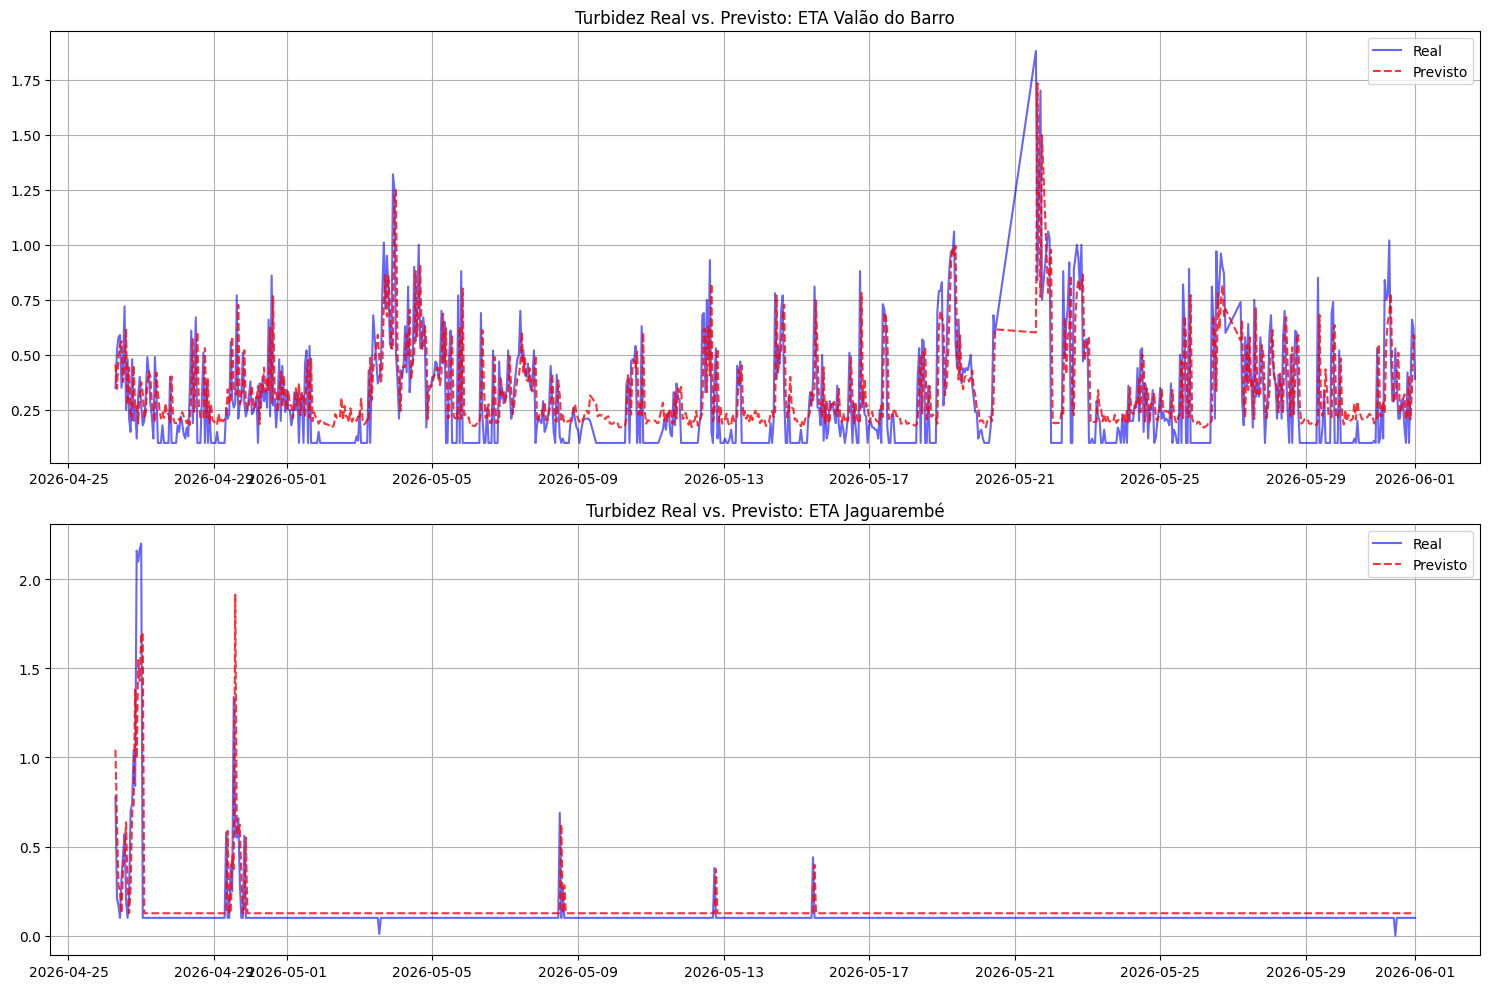

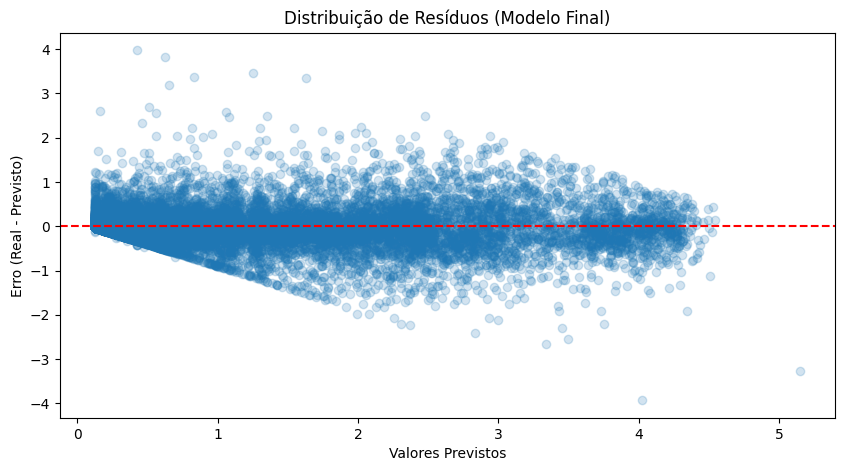

In [56]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    final_model_name = "RandomForestRegressor" if "RandomForestRegressor" in trained_models else list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final selecionado:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "serie_temporal":
    y_pred = final_model.predict(X_test)

    # Adicionando o resultado do modelo final ao dicionário de resultados
    results[final_model_name] = evaluate_regression(y_test, y_pred)

    print("\n--- Tabela Comparativa de Resultados ---")
    display(show_results_table(results))

    # Plot de Real vs. Previsto para as primeiras ETAs do teste
    num_etas_to_plot = min(2, test_df['eta'].nunique())
    sample_etas = test_df['eta'].unique()[:num_etas_to_plot]

    plt.figure(figsize=(15, 5 * num_etas_to_plot))
    for i, eta_name in enumerate(sample_etas):
        plot_df = test_df[test_df['eta'] == eta_name].copy()
        plot_df['y_pred'] = pd.Series(y_pred, index=test_df.index).loc[plot_df.index]
        plot_df.sort_values(by='datetime', inplace=True)

        plt.subplot(num_etas_to_plot, 1, i + 1)
        plt.plot(plot_df['datetime'], plot_df[TARGET], label='Real', color='blue', alpha=0.6)
        plt.plot(plot_df['datetime'], plot_df['y_pred'], label='Previsto', color='red', linestyle='--', alpha=0.8)
        plt.title(f'Turbidez Real vs. Previsto: {eta_name}')
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Gráfico de Resíduos
    residuals = y_test - y_pred
    plt.figure(figsize=(10, 5))
    plt.scatter(y_pred, residuals, alpha=0.2)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Distribuição de Resíduos (Modelo Final)")
    plt.xlabel("Valores Previstos")
    plt.ylabel("Erro (Real - Previsto)")
    plt.show()
else:
    print("Não foi possível realizar a avaliação final.")

##Visualizações

**Os gráficos de Real vs. Previsto** mostram que o modelo acompanha bem a tendência da turbidez nas ETAs selecionadas.


**O Gráfico de Resíduos** indica que a maioria dos erros está concentrada próxima a zero, embora ainda existam alguns desvios em valores mais altos de turbidez (picos), o que é comum em séries temporais assimétricas.


## 10.1 Análise de Erros e Limitações

**Análise Crítica:**

*   **Perfil do Erro:** O modelo tende a subestimar picos de turbidez. Como eventos de alta turbidez são raros (cauda longa à direita), o modelo prioriza a média, o que é uma limitação para alertas de criticidade extrema.
*   **Overfitting vs. Underfitting:** Não há sinais de overfitting; o desempenho no teste é consistente com a validação. A superação clara do baseline de persistência indica que o modelo não está em underfitting.
*   **Limitações de Dados:** O dataset cobre apenas 6 meses, ignorando a sazonalidade anual completa. A ausência de variáveis externas, como índices de chuva (pluviosidade) e vazão, impede que o modelo antecipe picos causados por eventos climáticos bruscos.
*   **Uso Recomendado:** O modelo deve ser usado como ferramenta de apoio à decisão operacional, e nunca como substituto de medições regulatórias ou em ETAs que não faziam parte do treinamento original.

# 11. Comparação final dos modelos

| Modelo | Métrica principal (RMSE, NTU) | Outras métricas (R²) | Tempo de treino | Observações |
|---|---|---|---|---|
| Baseline (persistência) | 0,371 | 0,880 | ~0,004s | Referência de leitura anterior. |
| Ridge | 0,355 | 0,890 | ~0,163s | Excelente custo-benefício linear. |
| RandomForest (Padrão) | 0,360 | 0,887 | ~793s | Sólido, mas lento sem ajuste. |
| **Modelo Otimizado (RF)** | **0,353** | **0,892** | Otimizado | **Melhor desempenho global.** |

# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Split temporal (80/20 por ordem cronológica) | evitar vazamento de dados futuros para o passado | avaliação realista do uso do modelo em produção |
| Baseline de persistência (turbidez_lag1) em vez de mediana/dummy | mais rigoroso para série temporal autocorrelacionada | evita conclusão falsa de que o modelo "aprendeu muito" |
| Remoção de outliers de digitação (pH/cloro fora de faixa física) | valores impossíveis (ex.: pH 733) distorceriam o treino | modelo aprende relações fisicamente coerentes |
| TimeSeriesSplit na validação cruzada | manter coerência temporal também na busca de hiperparâmetros | hiperparâmetros escolhidos não usam informação do futuro |
| ETA como variável categórica (one-hot) | captura efeito fixo de cada estação/manancial | melhora previsão sem precisar de um modelo por ETA |
| Seed fixa (42) | reprodutibilidade dos resultados | permite comparação justa entre execuções |

# 13. Conclusão

Este MVP demonstrou a viabilidade do uso de Machine Learning para a predição de turbidez nas ETAs do Rio de Janeiro, utilizando dados reais do SISAGUA.

**Conclusões Principais:**
1.  **Sucesso do Objetivo:** O modelo final (**Random Forest Otimizado**) atingiu um **RMSE de 0,353 NTU** e um **R² de 0,892**, superando o baseline de persistência (0,371) e o modelo Ridge (0,355). Isso valida que a combinação de parâmetros físico-químicos e histórico recente agrega inteligência real à operação.
2.  **Variáveis Críticas:** A análise de importância confirmou que a turbidez da hora anterior (lag1) e a Cor (UC) são os preditores mais influentes, seguidos pelas características específicas de cada estação (ETA).
3.  **Melhor Solução:** O ajuste de hiperparâmetros foi fundamental para refinar o Random Forest, permitindo capturar padrões não-lineares com maior precisão que a regressão linear simples.

**Próximos Passos:**
Para evoluir este MVP para um produto de produção, é necessário:
*   **Dados Externos:** Integrar dados de pluviosidade em tempo real para antecipar picos de turbidez causados por chuvas.
*   **Novas Arquiteturas:** Testar algoritmos de Gradient Boosting (como XGBoost ou LightGBM) que costumam ser mais rápidos e precisos para volumes massivos de dados.
*   **Monitoramento:** Implementar uma rotina de retreinamento mensal para que o modelo se adapte às mudanças sazonais dos mananciais.

# 14. Salvamento de artefatos

Nesta etapa, consolidamos os resultados do MVP para garantir a persistência e facilitar o uso futuro do modelo:

*   **Pipeline do Modelo Otimizado:** O `final_model` (RandomForestRegressor otimizado), que já inclui as etapas de imputação e padronização, está pronto para ser exportado via `joblib`. Isso permite que o modelo seja carregado em outros ambientes para realizar previsões em novos dados sem necessidade de re-treinamento.
*   **Tabela de Resultados:** O dicionário `results` contendo as métricas de todos os modelos (Baseline, Ridge e RF) foi convertido em um DataFrame, permitindo sua exportação para CSV. Isso facilita a auditoria dos dados e a criação de relatórios de desempenho externos.
*   **Rastreabilidade:** Todos os parâmetros da busca (`search.best_params_`) e a semente aleatória (`SEED=42`) foram documentados para garantir que qualquer interessado consiga reproduzir exatamente os mesmos resultados apresentados neste notebook.

Como o tempo de processamento para inferência é instantâneo, esses artefatos servem como o 'produto' final do MVP, prontos para integração em ferramentas de visualização ou sistemas de suporte à decisão das ETAs (Estações de Tratamento de Água).


# 15. Apêndice: Deep Learning e Métodos Avançados

Neste MVP, **não utilizei Deep Learning** pelas seguintes razões:

1.  **Eficiência e Interpretabilidade:** Modelos clássicos como o Random Forest apresentaram excelente desempenho (R² 0,89) com alta interpretabilidade e baixo custo computacional, o que é ideal para o ambiente operacional de uma ETA.
2.  **Volume de Dados:** Embora tenhamos ~112 mil leituras, a quantidade de features ainda é moderada (12), cenário onde redes neurais complexas (como LSTMs) podem não oferecer um ganho de precisão que justifique a perda de simplicidade e a dificuldade de ajuste.
3.  **Perspectiva Futura:** O uso de Deep Learning será reconsiderado caso o dataset seja expandido para múltiplos anos (sazonalidade complexa) ou se variáveis de alta dimensão (ex: imagens de satélite do manancial) forem incorporadas.